# 01 Extract: boundary, parcels, NAIP, lidar

Pulls every input onto one common grid so the later notebooks can compare
years with plain numpy.

1. Tahoe Keys boundary from the TRPA zoning service (plan area 102 plus special areas 1 and 2).
2. Parcels inside that zoning from the TRPA parcel service.
3. Summer 4-band NAIP for each year, read straight from Planetary Computer and warped onto the grid.
4. nDSM from the 2022 lidar DSM and DTM, plus the canopy and building masks.

Outputs land in `data/raw/` (source snapshots) and `data/processed/` (grid-aligned rasters).

In [1]:
import sys
from pathlib import Path

print(sys.executable)

# Make src/ importable whether the kernel starts in notebooks/ or the repo root
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from src.io import load_config, get_logger
from src import grid as G

cfg = load_config()
log = get_logger("01_extract")
log.info(f"Project: {cfg['project']['name']}")

RAW = ROOT / cfg["paths"]["raw"]
PROC = ROOT / cfg["paths"]["processed"]
for p in [RAW / "naip", RAW / "lidar", PROC]:
    p.mkdir(parents=True, exist_ok=True)

CRS = cfg["crs_epsg"]

2026-09-17 21:25:04 | INFO | 01_extract | Log file: <repo>/logs/01_extract_2026-09-17_212504.log


2026-09-17 21:25:04 | INFO | 01_extract | Project: tahoe-keys-lawn-change


/usr/bin/python3


In [2]:
import json
import numpy as np
import pandas as pd
import geopandas as gpd
import requests
import rasterio
from rasterio.vrt import WarpedVRT
from rasterio.enums import Resampling
from rasterio.features import rasterize
from scipy import ndimage
import matplotlib.pyplot as plt

## 1. Study boundary from the zoning service

`ZONING_ID` 102 is the Tahoe Keys plan area; 102_SA1 and 102_SA2 are its special areas.
Dissolved together they are the outer boundary of the Keys.

2026-09-17 21:25:05 | INFO | 01_extract | Zoning polygons: 3 -> ['Tahoe Keys', 'Tahoe Keys Special Area #2', 'Tahoe Keys Special Area #1']


2026-09-17 21:25:05 | INFO | 01_extract | Boundary area: 494.8 acres


Text(0.5, 1.0, 'Tahoe Keys boundary')

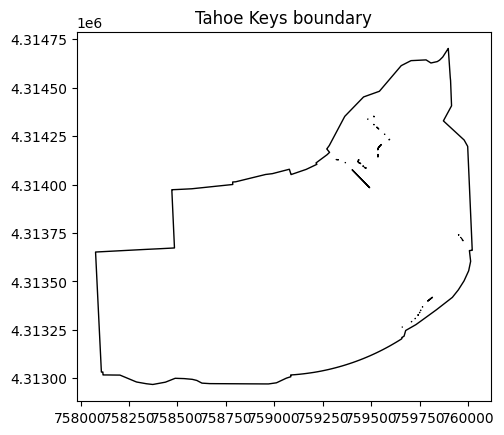

In [3]:
def rest_query(url, where, out_fields="*", out_sr=4326, page=2000):
    """Page through an ArcGIS REST layer and return a GeoDataFrame."""
    feats = []
    offset = 0
    while True:
        r = requests.get(f"{url}/query", params={
            "where": where, "outFields": out_fields, "returnGeometry": "true",
            "outSR": out_sr, "f": "geojson",
            "resultOffset": offset, "resultRecordCount": page,
        }, timeout=120)
        r.raise_for_status()
        gj = r.json()
        if "error" in gj:
            raise RuntimeError(gj["error"])
        batch = gj.get("features", [])
        feats.extend(batch)
        if len(batch) < page:
            break
        offset += page
    return gpd.GeoDataFrame.from_features(feats, crs=4326)


ids = ",".join(f"'{z}'" for z in cfg["sources"]["keys_zoning_ids"])
zoning = rest_query(cfg["sources"]["zoning_rest"], f"ZONING_ID IN ({ids})")
log.info(f"Zoning polygons: {len(zoning)} -> {zoning['ZONING_DESCRIPTION'].tolist()}")

zoning = zoning.to_crs(epsg=CRS)
boundary = gpd.GeoDataFrame(geometry=[zoning.union_all()], crs=zoning.crs)
boundary["name"] = "Tahoe Keys"
boundary["area_acres"] = boundary.area / 4046.856
log.info(f"Boundary area: {boundary['area_acres'].iloc[0]:,.1f} acres")

zoning.to_file(PROC / "keys_boundary.gpkg", layer="zoning", driver="GPKG")
boundary.to_file(PROC / "keys_boundary.gpkg", layer="boundary", driver="GPKG")
boundary.plot(edgecolor="k", facecolor="none").set_title("Tahoe Keys boundary")

## 2. Parcels

Selected on the same zoning IDs, so the parcel set and the boundary are defined the same way.
APN stays a string.

In [4]:
parcels = rest_query(
    cfg["sources"]["parcels_rest"],
    f"ZONING_ID IN ({ids})",
    out_fields="APN,APO_ADDRESS,JURISDICTION,COUNTY,EXISTING_LANDUSE,COUNTY_LANDUSE_DESCRIPTION,"
               "ZONING_ID,ZONING_DESCRIPTION,PARCEL_SQFT,PARCEL_ACRES,BUILDING_SQFT,"
               "IMPERVIOUS_SURFACE_SQFT,YEAR_BUILT,UNITS,CATCHMENT,WATERSHED_NAME,OWNERSHIP_TYPE",
)
parcels["APN"] = parcels["APN"].astype(str)
parcels = parcels.to_crs(epsg=CRS)
parcels = parcels[~parcels.geometry.is_empty & parcels.geometry.notna()].copy()

dups = parcels["APN"].duplicated(keep=False).sum()
if dups:
    log.warning(f"{dups} rows share an APN (split parcels). Dissolving to one geometry per APN.")
    parcels = parcels.dissolve(by="APN", aggfunc="first").reset_index()

parcels["parcel_m2"] = parcels.geometry.area
parcels["pid"] = np.arange(1, len(parcels) + 1, dtype=np.int32)  # raster ID, 0 = background

log.info(f"Parcels: {len(parcels):,}")
log.info("By existing land use:\n" + parcels["EXISTING_LANDUSE"].value_counts(dropna=False).to_string())
log.info("By zoning:\n" + parcels["ZONING_DESCRIPTION"].value_counts().to_string())

parcels.to_file(PROC / "keys_parcels.gpkg", layer="parcels", driver="GPKG")

2026-09-17 21:25:08 | INFO | 01_extract | Parcels: 1,450


2026-09-17 21:25:08 | INFO | 01_extract | By existing land use:
EXISTING_LANDUSE
Single Family Residential    1365
Vacant                         54
Open Space                     12
                                7
Commercial                      6
Multi-Family Residential        5
Public Service                  1


2026-09-17 21:25:08 | INFO | 01_extract | By zoning:
ZONING_DESCRIPTION
Tahoe Keys                    1137
Tahoe Keys Special Area #2     295
Tahoe Keys Special Area #1      18


## 3. The common grid

One grid for everything: analysis CRS, 0.6 m pixels, origin snapped so re-runs are identical.
Saved to `data/processed/grid.json` and reloaded by the other notebooks.

In [5]:
grid = G.make_grid(boundary.total_bounds, cfg["analysis"]["pixel_size_m"], CRS)
G.save_grid(grid, PROC / "grid.json")
log.info(f"Grid: {grid['width']} x {grid['height']} px at {grid['pixel_size']} m "
         f"({grid['width'] * grid['height'] / 1e6:.1f} Mpx)")

transform = G.grid_transform(grid)
shape = (grid["height"], grid["width"])

# Boundary mask and parcel ID raster (inset so fence lines and road edges don't count)
inset = cfg["analysis"]["parcel_inset_m"]
boundary_mask = rasterize(
    [(geom, 1) for geom in boundary.geometry], out_shape=shape, transform=transform, dtype="uint8"
)
parcel_id = rasterize(
    [(geom.buffer(-inset), pid) for geom, pid in zip(parcels.geometry, parcels["pid"]) if not geom.buffer(-inset).is_empty],
    out_shape=shape, transform=transform, dtype="int32", fill=0,
)
G.write_raster(PROC / "boundary_mask.tif", boundary_mask, grid, nodata=0)
G.write_raster(PROC / "parcel_id.tif", parcel_id, grid, nodata=0)
log.info(f"Parcel raster covers {(parcel_id > 0).sum() * G.pixel_area_m2(grid) / 4046.856:,.1f} acres "
         f"across {len(np.unique(parcel_id)) - 1:,} parcels")

2026-09-17 21:25:08 | INFO | 01_extract | Grid: 3341 x 2992 px at 0.6 m (10.0 Mpx)


2026-09-17 21:25:09 | INFO | 01_extract | Parcel raster covers 413.1 acres across 1,450 parcels


## 4. NAIP from Planetary Computer

For each year, find the quarter quads that touch the boundary, warp each straight from the
cloud-optimized GeoTIFF onto the common grid, and mosaic. The acquisition date is written
into the GeoTIFF tags because it drives the interpretation later: a September image and a
June image of the same lawn are not the same measurement.

Years that are not on Planetary Computer (2024 at the time of writing) come from
`sources.naip.local` in `config.yaml`.

In [6]:
import pystac_client
import planetary_computer

catalog = pystac_client.Client.open(cfg["sources"]["naip"]["stac_url"], modifier=planetary_computer.sign_inplace)
bbox_wgs84 = boundary.to_crs(4326).total_bounds.tolist()


def warp_to_grid(src, grid, resampling=Resampling.bilinear):
    """Read a raster onto the common grid. Returns (bands, rows, cols) array."""
    with WarpedVRT(
        src, crs=rasterio.crs.CRS.from_epsg(grid["crs_epsg"]), transform=G.grid_transform(grid),
        width=grid["width"], height=grid["height"], resampling=resampling,
    ) as vrt:
        return vrt.read()


def mosaic_items(hrefs, dates, grid):
    """
    Mosaic several quarter quads onto the grid. First valid pixel wins, so pass
    hrefs in priority order. Also returns a per-pixel date index (1-based into
    the sorted unique date list) so a parcel can be tagged with the date it
    was actually imaged when a year mixes flight dates.
    """
    out = np.zeros((4, grid["height"], grid["width"]), dtype="uint8")
    date_idx = np.zeros((grid["height"], grid["width"]), dtype="uint8")
    unique_dates = sorted(set(dates))
    for href, d in zip(hrefs, dates):
        with rasterio.open(href) as src:
            arr = warp_to_grid(src, grid)[:4]
        fill = (out.sum(axis=0) == 0) & (arr.sum(axis=0) > 0)
        out[:, fill] = arr[:, fill]
        date_idx[fill] = unique_dates.index(d) + 1
    return out, date_idx, unique_dates


from shapely.geometry import box as shp_box
boundary_wgs = boundary.to_crs(4326).geometry.iloc[0]


def item_priority(item):
    """Quads covering more of the Keys come first; CA quads beat NV quads on ties."""
    overlap = shp_box(*item.bbox).intersection(boundary_wgs).area
    return (-overlap, 0 if item.id.startswith("ca_") else 1)


naip_index = []
for year in cfg["sources"]["naip"]["years"]:
    out_path = RAW / "naip" / f"naip_{year}.tif"
    search = catalog.search(collections=[cfg["sources"]["naip"]["collection"]], bbox=bbox_wgs84,
                            datetime=f"{year}-01-01/{year}-12-31")
    items = [it for it in search.items() if it.properties.get("naip:year") == str(year) or it.datetime.year == year]
    # Keep the finest GSD available for the year (CA 0.6 m over NV 1 m where both appear)
    if items:
        best_gsd = min(it.properties.get("gsd", 1.0) for it in items)
        items = [it for it in items if it.properties.get("gsd", 1.0) == best_gsd]
    if not items:
        log.warning(f"{year}: no NAIP items found on Planetary Computer")
        continue
    items = sorted(items, key=item_priority)
    item_dates = [it.datetime.date().isoformat() for it in items]
    dates = sorted(set(item_dates))
    log.info(f"{year}: {len(items)} quads, dates {dates}, gsd {best_gsd}, priority order {[it.id for it in items]}")
    if out_path.exists():
        log.info(f"{year}: {out_path.name} exists, skipping download")
    else:
        arr, date_idx, unique_dates = mosaic_items([it.assets["image"].href for it in items], item_dates, grid)
        G.write_raster(out_path, arr, grid, nodata=0, tags={
            "year": str(year), "acq_dates": ";".join(unique_dates), "source": "NAIP via Planetary Computer",
            "items": ";".join(it.id for it in items), "bands": "R,G,B,NIR",
        })
        G.write_raster(RAW / "naip" / f"naip_{year}_date.tif", date_idx, grid, nodata=0,
                       tags={"dates": ";".join(unique_dates), "note": "pixel value = 1-based index into dates"})
        inside = parcel_id > 0
        share = {d: float((date_idx[inside] == i + 1).mean()) for i, d in enumerate(unique_dates)}
        log.info(f"{year}: share of parcel pixels by flight date {share}")
    naip_index.append({"year": year, "acq_dates": ";".join(dates), "n_quads": len(items), "gsd": best_gsd,
                       "path": str(out_path.relative_to(ROOT)), "source": "planetary_computer"})

2026-09-17 21:25:12 | INFO | 01_extract | 2016: 4 quads, dates ['2016-07-12', '2016-07-21'], gsd 0.6, priority order ['ca_m_3812008_se_10_.6_20160712_20161004', 'ca_m_3812008_ne_10_.6_20160712_20161004', 'ca_m_3811901_sw_11_.6_20160721_20161004', 'ca_m_3811901_nw_11_.6_20160721_20161004']


2026-09-17 21:25:31 | INFO | 01_extract | 2016: share of parcel pixels by flight date {'2016-07-12': 1.0, '2016-07-21': 0.0}


2026-09-17 21:25:31 | INFO | 01_extract | 2018: 4 quads, dates ['2018-09-10', '2018-09-17'], gsd 0.6, priority order ['ca_m_3812008_se_10_060_20180917_20190209', 'ca_m_3812008_ne_10_060_20180917_20190209', 'ca_m_3811901_sw_11_060_20180910_20190210', 'ca_m_3811901_nw_11_060_20180910_20190210']


2026-09-17 21:25:43 | INFO | 01_extract | 2018: share of parcel pixels by flight date {'2018-09-10': 0.0, '2018-09-17': 1.0}


2026-09-17 21:25:44 | INFO | 01_extract | 2020: 4 quads, dates ['2020-07-24', '2020-07-31'], gsd 0.6, priority order ['ca_m_3812008_se_10_060_20200731', 'ca_m_3812008_ne_10_060_20200724', 'ca_m_3811901_sw_11_060_20200731', 'ca_m_3811901_nw_11_060_20200731']


2026-09-17 21:25:59 | INFO | 01_extract | 2020: share of parcel pixels by flight date {'2020-07-24': 0.08091104571765964, '2020-07-31': 0.9190889542823404}


2026-09-17 21:25:59 | INFO | 01_extract | 2022: 6 quads, dates ['2022-06-10', '2022-07-21', '2022-08-13'], gsd 0.6, priority order ['ca_m_3812008_se_10_060_20220721', 'ca_m_3812008_ne_10_060_20220721', 'nv_m_3812008_ne_10_060_20220721', 'ca_m_3811901_sw_11_060_20220813', 'ca_m_3811901_nw_11_060_20220813', 'nv_m_3811901_nw_11_060_20220610']


2026-09-17 21:26:15 | INFO | 01_extract | 2022: share of parcel pixels by flight date {'2022-06-10': 0.0, '2022-07-21': 1.0, '2022-08-13': 0.0}


In [7]:
# Local years (not on Planetary Computer). Bands must be R,G,B,NIR.
for year, path in (cfg["sources"]["naip"].get("local") or {}).items():
    if not path:
        log.info(f"{year}: no local file configured, skipping")
        continue
    year = int(year)
    src_path = ROOT / path
    out_path = RAW / "naip" / f"naip_{year}.tif"
    if not src_path.exists():
        log.warning(f"{year}: configured local NAIP not found at {src_path}")
        continue
    paths = sorted(src_path.glob("*.tif")) if src_path.is_dir() else [src_path]
    # NAIP file names carry the flight date as the trailing YYYYMMDD token; fall back to "unknown"
    def date_from_name(p):
        tok = [t for t in p.stem.split("_") if len(t) == 8 and t.isdigit()]
        return f"{tok[-1][:4]}-{tok[-1][4:6]}-{tok[-1][6:]}" if tok else "unknown"
    file_dates = [date_from_name(p) for p in paths]
    arr, date_idx, unique_dates = mosaic_items([str(p) for p in paths], file_dates, grid)
    acq = ";".join(unique_dates)
    G.write_raster(out_path, arr, grid, nodata=0, tags={"year": str(year), "acq_dates": acq, "source": "local", "bands": "R,G,B,NIR"})
    G.write_raster(RAW / "naip" / f"naip_{year}_date.tif", date_idx, grid, nodata=0, tags={"dates": acq})
    log.info(f"{year}: wrote {out_path.name} from {len(paths)} local file(s), acq {acq}")
    naip_index.append({"year": year, "acq_dates": acq, "n_quads": len(paths), "gsd": None,
                       "path": str(out_path.relative_to(ROOT)), "source": "local"})

naip_index = pd.DataFrame(naip_index).sort_values("year")
naip_index.to_csv(PROC / "naip_index.csv", index=False)
naip_index

2026-09-17 21:26:15 | INFO | 01_extract | 2024: no local file configured, skipping


,year,acq_dates,n_quads,gsd,path,source
0,2016,2016-07-12;2016-07-21,4,0.6,data/raw/naip/naip_2016.tif,planetary_computer
1,2018,2018-09-10;2018-09-17,4,0.6,data/raw/naip/naip_2018.tif,planetary_computer
2,2020,2020-07-24;2020-07-31,4,0.6,data/raw/naip/naip_2020.tif,planetary_computer
3,2022,2022-06-10;2022-07-21;2022-08-13,6,0.6,data/raw/naip/naip_2022.tif,planetary_computer


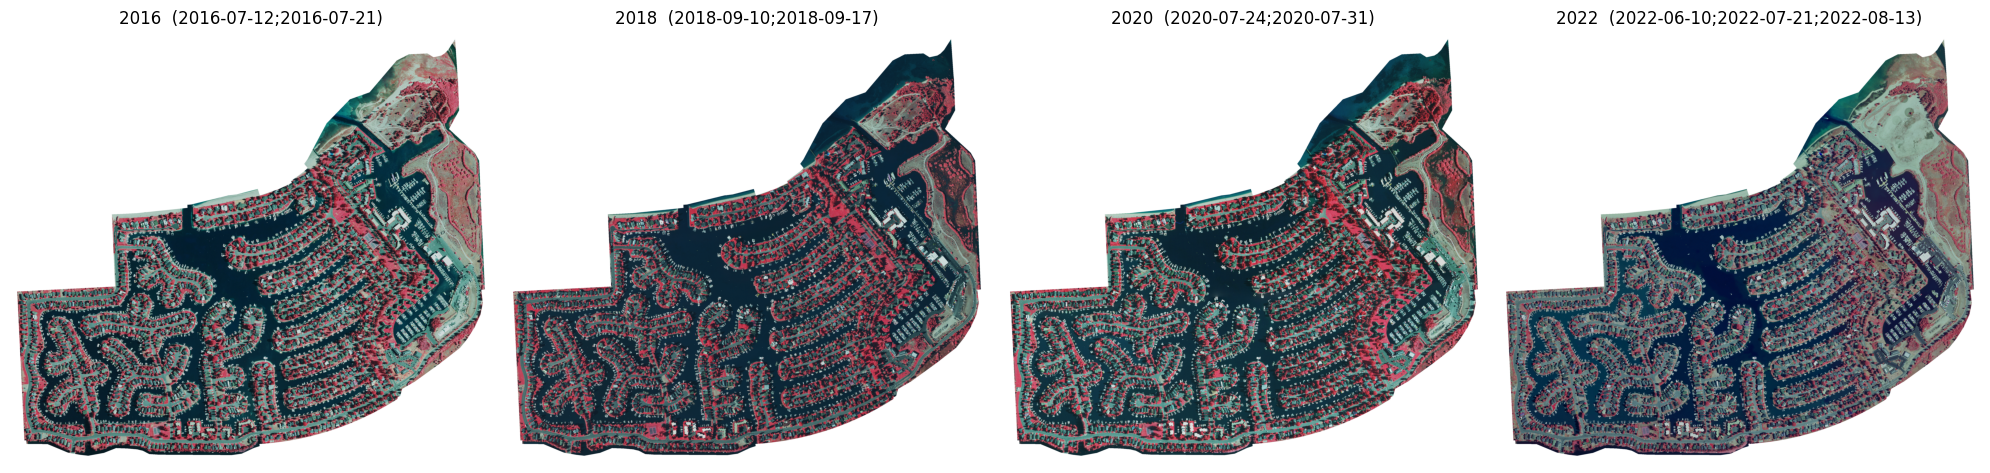

In [8]:
# Quicklook: false colour (NIR, R, G) for each year, clipped to the boundary
years = naip_index["year"].tolist()
fig, axes = plt.subplots(1, len(years), figsize=(5 * len(years), 5))
for ax, year in zip(np.atleast_1d(axes), years):
    arr, tags = G.read_raster(RAW / "naip" / f"naip_{year}.tif", grid)
    rgb = np.stack([arr[3], arr[0], arr[1]], axis=-1).astype(float) / 255
    rgb[boundary_mask == 0] = 1
    ax.imshow(rgb)
    ax.set_title(f"{year}  ({tags.get('acq_dates')})")
    ax.axis("off")
plt.tight_layout()

## 5. Lidar: nDSM, canopy mask, building mask

nDSM = DSM minus DTM, warped onto the grid. Anything at or above `canopy_height_m` is not lawn.
The canopy mask is then grown by `canopy_buffer_m` to swallow the shadow fringe on the sunlit
side of each tree and any lidar-to-imagery offset. The 2022 mask is applied to every year;
see METHODS.md for why that is acceptable here.

If the lidar files are not present the notebook writes an all-zero nDSM and flags it, so the
rest of the pipeline can be exercised. Do not trust lawn numbers produced that way.

In [9]:
lidar_cfg = cfg["sources"]["lidar"]
dsm_path, dtm_path = ROOT / lidar_cfg["dsm"], ROOT / lidar_cfg["dtm"]
px = grid["pixel_size"]

if dsm_path.exists() and dtm_path.exists():
    with rasterio.open(dsm_path) as s:
        dsm = warp_to_grid(s, grid)[0].astype("float32")
        dsm_nodata = s.nodata
    with rasterio.open(dtm_path) as s:
        dtm = warp_to_grid(s, grid)[0].astype("float32")
        dtm_nodata = s.nodata
    valid = np.isfinite(dsm) & np.isfinite(dtm)
    if dsm_nodata is not None:
        valid &= dsm != dsm_nodata
    if dtm_nodata is not None:
        valid &= dtm != dtm_nodata
    ndsm = np.where(valid, np.clip(dsm - dtm, 0, None), np.nan).astype("float32")
    lidar_ok = True
    log.info(f"nDSM built from {dsm_path.name} and {dtm_path.name}; "
             f"{np.isnan(ndsm).mean() * 100:.1f}% nodata inside grid")
else:
    ndsm = np.zeros(shape, dtype="float32")
    lidar_ok = False
    log.warning("LIDAR NOT FOUND: using an all-zero nDSM. Canopy will NOT be masked. Results are for pipeline testing only.")

G.write_raster(PROC / "ndsm.tif", np.nan_to_num(ndsm, nan=-9999), grid, nodata=-9999,
               tags={"lidar_year": str(lidar_cfg["year"]), "lidar_ok": str(lidar_ok)})

# Canopy / structure mask: tall pixels, grown outward by the buffer
tall = np.nan_to_num(ndsm, nan=0) >= cfg["analysis"]["canopy_height_m"]
buffer_px = int(np.ceil(cfg["analysis"]["canopy_buffer_m"] / px))
if buffer_px > 0:
    yy, xx = np.ogrid[-buffer_px:buffer_px + 1, -buffer_px:buffer_px + 1]
    disk = (xx ** 2 + yy ** 2) <= buffer_px ** 2
    tall_buf = ndimage.binary_dilation(tall, structure=disk)
else:
    tall_buf = tall
G.write_raster(PROC / "canopy_mask.tif", tall_buf.astype("uint8"), grid, nodata=None,
               tags={"height_m": str(cfg["analysis"]["canopy_height_m"]), "buffer_m": str(cfg["analysis"]["canopy_buffer_m"])})

inside = parcel_id > 0
log.info(f"Tall (>= {cfg['analysis']['canopy_height_m']} m) share of parcel area: {tall[inside].mean() * 100:.1f}%; "
         f"after {cfg['analysis']['canopy_buffer_m']} m buffer: {tall_buf[inside].mean() * 100:.1f}%")

2026-09-17 21:26:22 | WARNING | 01_extract | LIDAR NOT FOUND: using an all-zero nDSM. Canopy will NOT be masked. Results are for pipeline testing only.


2026-09-17 21:26:22 | INFO | 01_extract | Tall (>= 0.5 m) share of parcel area: 0.0%; after 1.0 m buffer: 0.0%


In [10]:
# Building mask. Preferred: a footprint layer. Fallback: tall + flat + not green in the lidar-year image.
fp = lidar_cfg.get("building_footprints")
if fp and (ROOT / fp).exists():
    bld = gpd.read_file(ROOT / fp).to_crs(epsg=CRS)
    building = rasterize([(g, 1) for g in bld.geometry], out_shape=shape, transform=transform, dtype="uint8")
    log.info(f"Building mask from {fp}: {len(bld):,} footprints")
elif lidar_ok:
    ref_year = min(cfg["sources"]["naip"]["years"], key=lambda y: abs(y - lidar_cfg["year"]))
    arr, _ = G.read_raster(RAW / "naip" / f"naip_{ref_year}.tif", grid)
    red, nir = arr[0].astype(float), arr[3].astype(float)
    ndvi_ref = (nir - red) / np.maximum(nir + red, 1)
    # roofs: >= 2.5 m, low local height variance, not green
    h = np.nan_to_num(ndsm, nan=0)
    local_std = ndimage.generic_filter(h, np.std, size=5)
    building = ((h >= 2.5) & (local_std < 0.6) & (ndvi_ref < 0.2)).astype("uint8")
    building = ndimage.binary_opening(building, iterations=2).astype("uint8")
    log.info(f"Building mask derived from nDSM + {ref_year} NDVI (no footprint layer configured)")
else:
    building = np.zeros(shape, dtype="uint8")
    log.warning("No building mask (no footprints and no lidar)")
G.write_raster(PROC / "building_mask.tif", building, grid)

2026-09-17 21:26:22 | WARNING | 01_extract | No building mask (no footprints and no lidar)


## 6. Alignment check and extract summary

In [11]:
checks = {}
for name in ["boundary_mask", "parcel_id", "ndsm", "canopy_mask", "building_mask"] + [f"naip_{y}" for y in years]:
    p = (RAW / "naip" / f"{name}.tif") if name.startswith("naip") else (PROC / f"{name}.tif")
    with rasterio.open(p) as s:
        checks[name] = (s.width == grid["width"] and s.height == grid["height"]
                        and abs(s.transform.c - grid["origin_x"]) < 1e-3 and abs(s.transform.f - grid["origin_y"]) < 1e-3)
bad = [k for k, v in checks.items() if not v]
if bad:
    log.error(f"Rasters off the common grid: {bad}")
else:
    log.info(f"All {len(checks)} rasters on the common grid")

summary = {
    "boundary_acres": float(boundary["area_acres"].iloc[0]),
    "parcels": int(len(parcels)),
    "naip_years": years,
    "naip_dates": naip_index.set_index("year")["acq_dates"].to_dict(),
    "lidar_ok": lidar_ok,
    "grid": grid,
}
(PROC / "extract_summary.json").write_text(json.dumps(summary, indent=2, default=str))
log.info("01_extract complete")
summary

2026-09-17 21:26:22 | INFO | 01_extract | All 9 rasters on the common grid


2026-09-17 21:26:22 | INFO | 01_extract | 01_extract complete


{'boundary_acres': 494.83864054559757,
 'parcels': 1450,
 'naip_years': [2016, 2018, 2020, 2022],
 'naip_dates': {2016: '2016-07-12;2016-07-21',
  2018: '2018-09-10;2018-09-17',
  2020: '2020-07-24;2020-07-31',
  2022: '2022-06-10;2022-07-21;2022-08-13'},
 'lidar_ok': False,
 'grid': {'crs_epsg': 26910,
  'pixel_size': 0.6,
  'origin_x': 758047.2,
  'origin_y': 4314733.2,
  'width': 3341,
  'height': 2992}}